In [1]:
import numpy as np
from datetime import datetime
import pandas as pd
from pathlib import Path
import hydra

# Definición de constantes

In [2]:
SEED = 11
SCENARIO: str = 'Synthetic_Temporal'
# TODO: cambiar a ruta relativa
# Localizar la raíz del proyecto (subiendo 3 niveles desde src/components/scenario_creation)
# O simplemente definiendo la ruta relativa desde donde se ejecuta el notebook
PROJECT_ROOT = Path.cwd().parent.parent.parent 
SAVING_ROUTE = PROJECT_ROOT / "data" / "raw" / SCENARIO

# Crear la carpeta si no existe (parents=True crea las carpetas intermedias)
SAVING_ROUTE.mkdir(parents=True, exist_ok=True)


FILES_NAMING_DICTIONARY = {
    "nodes": f"{SCENARIO}_node.tntp",
    "network": f"{SCENARIO}_net.tntp",
    "trips": f"{SCENARIO}_trips.tntp",
    "routes": f"{SCENARIO}_routes.tntp",
    "flows": f"{SCENARIO}_flow.tntp"
}

## Procesamiento de Nodos

In [3]:
# Procesamiento de nodes

import matplotlib.pyplot as plt
# 1. Generar una lista de nodos con sus atributos (tipo, ID, coordenadas)
# 2. Visualizar

✓ Validations passed: Nones are consistent.


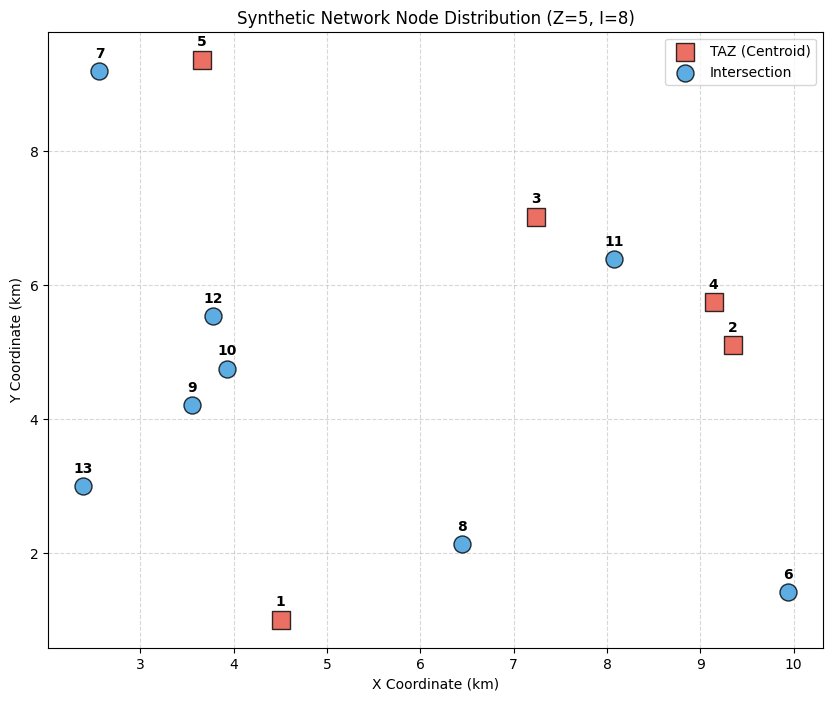

In [4]:

# Definición de constantes: nodes
possible_node_types = ['intersection', 'taz', 'aux']
NUM_ZONES: int = 5
NUM_TAZ: int = 5
NUM_AUX: int = 0
NUM_INTERSECTIONS: int = 8

if NUM_ZONES != (NUM_TAZ + NUM_AUX):
    raise ValueError(
        f"Inconsistency in Zones: NUM_ZONES ({NUM_ZONES}) must be equal "
        f"to NUM_TAZ ({NUM_TAZ}) + NUM_AUX ({NUM_AUX})."
    )

print("✓ Validations passed: Nones are consistent.")

#%%

# --- 2. Node Generation Logic ---
# Logic: In TNTP, nodes 1 to NUM_ZONES are always reserved for zones.
nodes = []

# TAZ Nodes (Centroids)
for i in range(1, NUM_TAZ + 1):
    nodes.append({
        'node_id': i,
        'node_type': 'taz',
        'x': np.random.uniform(0, 10),
        'y': np.random.uniform(0, 10)
    })

# AUX Nodes (Gateways/External Zones)
for i in range(NUM_TAZ + 1, NUM_ZONES + 1):
    nodes.append({
        'node_id': i,
        'node_type': 'aux',
        'x': np.random.uniform(0, 10),
        'y': np.random.uniform(0, 10)
    })

# Intersection Nodes (Physical Infrastructure)
for i in range(NUM_ZONES + 1, NUM_ZONES + NUM_INTERSECTIONS + 1):
    nodes.append({
        'node_id': i,
        'node_type': 'intersection',
        'x': np.random.uniform(0, 10),
        'y': np.random.uniform(0, 10)
    })

node_df = pd.DataFrame(nodes)

# --- 3. Visualization ---
plt.figure(figsize=(10, 8))
styles = {
    'taz': {'color': '#e74c3c', 'marker': 's', 'label': 'TAZ (Centroid)'},
    'aux': {'color': '#2ecc71', 'marker': '^', 'label': 'AUX (Gateway)'},
    'intersection': {'color': '#3498db', 'marker': 'o', 'label': 'Intersection'}
}

for n_type, style in styles.items():
    subset = node_df[node_df['node_type'] == n_type]
    if not subset.empty:
        plt.scatter(subset['x'], subset['y'], 
                    c=style['color'], marker=style['marker'], 
                    label=style['label'], s=150, edgecolors='black', alpha=0.8, zorder=3)
        
        # ID Annotations
        for _, row in subset.iterrows():
            plt.annotate(str(int(row['node_id'])), (row['x'], row['y']),
                         textcoords="offset points", xytext=(0,10), 
                         ha='center', fontsize=10, fontweight='bold')

plt.title(f"Synthetic Network Node Distribution (Z={NUM_ZONES}, I={NUM_INTERSECTIONS})")
plt.xlabel("X Coordinate (km)")
plt.ylabel("Y Coordinate (km)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.savefig("synthetic_nodes_distribution.png")

In [5]:
node_df

,node_id,node_type,x,y
0,1,taz,4.504902,1.002333
1,2,taz,9.351034,5.103920
2,3,taz,7.243727,7.023901
3,4,taz,9.143387,5.750562
4,5,taz,3.663048,9.367192
5,6,intersection,9.939209,1.410564
6,7,intersection,2.562379,9.193109
7,8,intersection,6.451032,2.130747
8,9,intersection,3.557771,4.207431
9,10,intersection,3.931099,4.752406


### Nodes: tntp

In [6]:
# 1. Preparar el DataFrame para la exportación
# Copiamos para no alterar el dataframe original de trabajo
export_df = node_df.copy()

# 2. Reorganizar y renombrar columnas
# El formato TNTP pide: Node, Node id, X, Y, Type
export_df['Node'] = range(1, len(export_df) + 1) # Índice secuencial 1..N
export_df = export_df.rename(columns={
    'node_id': 'Node id',
    'x': 'X',
    'y': 'Y',
    'node_type': 'Type'
})

# Reordenar las columnas al orden exacto solicitado
export_df = export_df[['Node', 'Node id', 'X', 'Y', 'Type']]

# 3. Definir la ruta de guardado usando tus variables previas
nodes_file_path = SAVING_ROUTE / FILES_NAMING_DICTIONARY['nodes']

# 4. Exportar
# Usamos sep='\t' para tabulaciones, index=False para no repetir el índice de pandas
export_df.to_csv(nodes_file_path, sep='\t', index=False)

print(f"✓ Nodes exported to: {nodes_file_path}")

✓ Nodes exported to: /home/jeclareyes/Documents/DL_Pipeline_AADT/DL_Pipeline_AADT/data/raw/Synthetic_Temporal/Synthetic_Temporal_node.tntp


## Procesamiento de trips

In [7]:
# Procesamiento de trips
from datetime import datetime, timedelta
import numpy as np
from ipywidgets import interact, IntSlider, fixed
import seaborn as sns
# 1. Definir una distribución de probabilidad para seleccionar el origen y destino de los viajes entre las zonas (TAZ + AUX)
# 2. Generar una matriz OD (origen-destino) basada en la distribución definida, por día y hora
# 3. Verificar el formato y consistencia de la matriz OD generada
# 4. Visualizar la matriz OD

In [8]:
# Definición de constantes: trips

NUM_DAYS: int = 10
STARTING_DATE: str = "2024-01-01"

start_dt = datetime.strptime(STARTING_DATE, "%Y-%m-%d")

In [9]:
np.random.seed(SEED) # For reproducibility in this example

# --- 1. Definición de la Demanda Base ---
# Solo nodos TAZ/AUX (1 a NUM_ZONES) tienen demanda
demand_nodes = list(range(1, NUM_ZONES + 1))
all_nodes = list(range(1, NUM_ZONES + NUM_INTERSECTIONS + 1))

base_demand = np.zeros((NUM_ZONES + 1, NUM_ZONES + 1))
for o in demand_nodes:
    for d in demand_nodes:
        if o != d:
            base_demand[o, d] = np.random.uniform(0, 20)

# --- 2. Perfil Horario Bimodal ---
hourly_profile = []
for h in range(24):
    if 12 <= h <= 14 or 19 <= h <= 21: # Picos
        m = np.random.uniform(1.5, 1.7)
    elif 0 <= h <= 6: # Valles
        m = np.random.uniform(0.1, 0.3)
    else: # Transiciones
        m = np.random.uniform(0.7, 1.1)
    hourly_profile.append(m)


### Trips: tntp

In [10]:

# --- 3. Escritura del Archivo TNTP ---
tntp_lines = [f"<NUMBER OF ZONES> {NUM_ZONES}", "<END OF METADATA>", ""]
start_date = datetime.strptime(STARTING_DATE, "%Y-%m-%d")

for d_idx in range(NUM_DAYS):
    curr_date = (start_date + timedelta(days=d_idx)).strftime("%Y-%m-%d")
    for h in range(24):
        tntp_lines.append(f"<MATRIX DATE> {curr_date} {h:02d}:00")
        for o in demand_nodes:
            tntp_lines.append(f"Origin {o}")
            row = "    "
            for i, d in enumerate(all_nodes):
                # Aplicar ruido stocástico del 5%
                noise = np.random.uniform(0.95, 1.05)
                flow = base_demand[o, d] * hourly_profile[h] * noise if d <= NUM_ZONES else 0.0
                row += f"{d} : {flow:.2f}; "
                if (i + 1) % 6 == 0: # Formato de 6 entradas por línea
                    tntp_lines.append(row.strip())
                    row = "    "
            if row.strip(): tntp_lines.append(row.strip())
        tntp_lines.append("")

with open(Path(SAVING_ROUTE, FILES_NAMING_DICTIONARY['trips']), "w") as f:
    f.write("\n".join(tntp_lines))

In [11]:
# --- 1. Generación de Datos en Memoria ---
# (Asumiendo que ya tienes NUM_DAYS, NUM_ZONES, base_demand y hourly_profile)

# Creamos un contenedor para todas las matrices: (Días, Horas, Origen, Destino)
# Usamos NUM_ZONES + 1 para que el índice coincida con el ID del nodo
all_data = np.zeros((NUM_DAYS, 24, NUM_ZONES + 1, NUM_ZONES + 1))

for d_idx in range(NUM_DAYS):
    for h in range(24):
        for o in range(1, NUM_ZONES + 1):
            for d in range(1, NUM_ZONES + 1):
                if o != d:
                    noise = np.random.uniform(0.95, 1.05)
                    flow = base_demand[o, d] * hourly_profile[h] * noise
                    all_data[d_idx, h, o, d] = flow


# --- 1. Pre-cálculo de la demanda total por hora para el gráfico de líneas ---
# Sumamos sobre los ejes de origen (2) y destino (3)
hourly_totals = all_data.sum(axis=(2, 3)) 

def plot_dual_dashboard(day_idx, hour, data, totals):
    # Creamos una figura con dos columnas: 1 para el heatmap, 1 para el perfil
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1.2, 1]})
    
    # --- A. HEATMAP (Izquierda) ---
    matrix_to_plot = data[day_idx, hour, 1:, 1:]
    sns.heatmap(matrix_to_plot, 
                annot=True,       # Muestra los números
                fmt=".1f",        # Un decimal para no saturar
                cmap="YlGnBu", 
                ax=ax1, 
                cbar_kws={'label': 'Nº de Viajes'})
    
    ax1.set_title(f"Matriz OD - Día {day_idx} | Hora {hour:02d}:00", fontsize=14)
    ax1.set_xlabel("Nodo Destino")
    ax1.set_ylabel("Nodo Origen")

    # --- B. PERFIL TEMPORAL (Derecha) ---
    current_day_profile = totals[day_idx]
    ax2.plot(range(24), current_day_profile, color='gray', linestyle='--', alpha=0.5, label='Demanda diaria')
    ax2.scatter(hour, current_day_profile[hour], color='red', s=100, zorder=5, label='Hora seleccionada')
    
    # Resaltar la curva actual
    ax2.fill_between(range(24), current_day_profile, color='skyblue', alpha=0.3)
    ax2.set_xticks(range(24))
    ax2.set_title(f"Evolución de la Demanda - Día {day_idx}", fontsize=14)
    ax2.set_xlabel("Hora del día")
    ax2.set_ylabel("Total de Viajes (Suma OD)")
    ax2.grid(True, axis='y', alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# --- Ejecutar Dashboard ---
interact(
    plot_dual_dashboard, 
    day_idx=IntSlider(min=0, max=NUM_DAYS-1, step=1, description='Día:'),
    hour=IntSlider(min=0, max=23, step=1, description='Hora:'),
    data=fixed(all_data),
    totals=fixed(hourly_totals)
);

interactive(children=(IntSlider(value=0, description='Día:', max=9), IntSlider(value=0, description='Hora:', m…

## Procesamiento de network

In [12]:
# Procesamiento de network

# 1. Conectar los nodos TAZ y AUX a los nodos de intersección más cercanos
# 2. Generar enlaces entre nodos de intersección basados en reglas de conectividad
# 3. Asignar propiedades a los enlaces generados utilizando las constantes definidas anteriormente
# 4. Visualizar la red generada (junto con los nodes)

In [13]:
# Definición de tipos de infraestructura
NETWORK_CATALOG = {
    "link_types": {
        1: {
            "description": "Highways",
            "capacity": 1800,
            "lanes": 2,
            "toll": 0,  # Assuming toll is a binary attribute (0 for no toll, 1 for toll)
            "allowed_vdfs": [1]  # List of VDF IDs compatible with this type
        },
        2: {
            "description": "Arterials",
            "capacity": 900,
            "lanes": 1,
            "toll": 0,
            "allowed_vdfs": [1, 2] # Can have multiple VDF profiles
        },
        99: {
            "description": "Connectors (Auxiliary)",
            "capacity": 9999,
            "lanes": 1,
            "toll": 0,
            "allowed_vdfs": [99]
        }
    },
    "vdf_profiles": {
        1: {"b": 0.15, "power": 4.0, "speed_limit": 60.0},
        2: {"b": 0.20, "power": 5.0, "speed_limit": 45.0},
        99: {"b": 0.0, "power": 1.0, "speed_limit": 9999.0}
    }
}

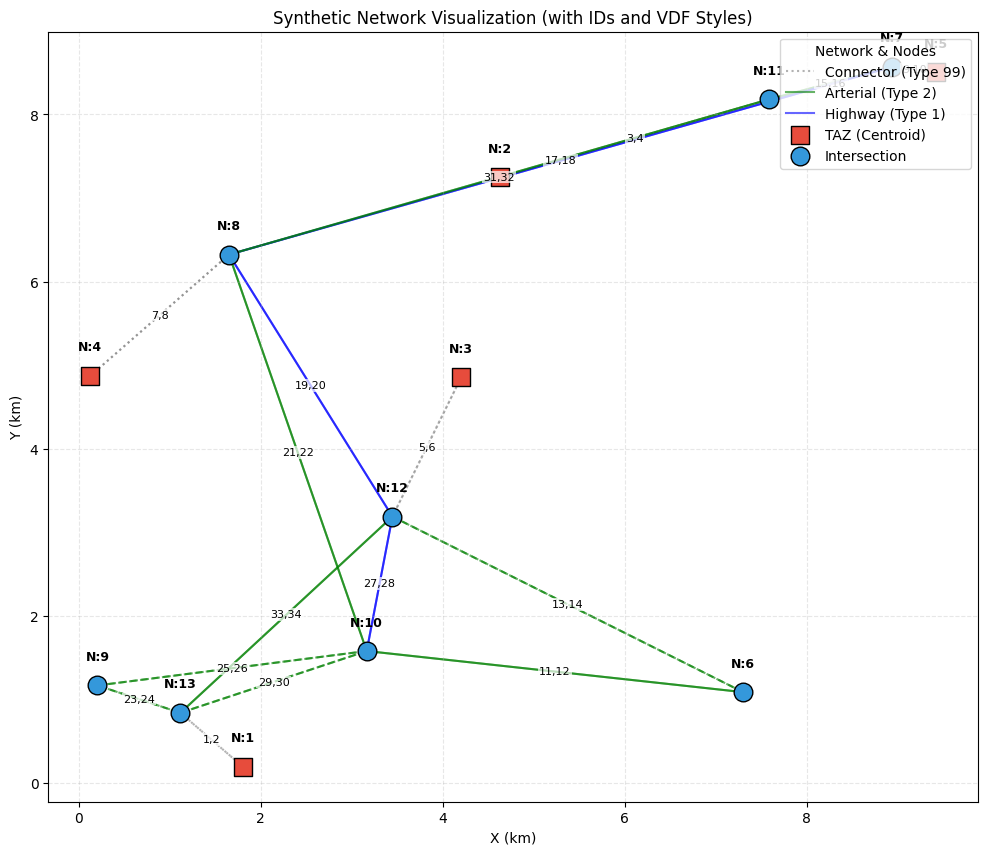

In [14]:
# --- 2. Node Generation ---
np.random.seed(SEED) # For reproducibility in this example
nodes = []
for i in range(1, NUM_TAZ + 1):
    nodes.append({'node_id': i, 'node_type': 'taz', 'x': np.random.uniform(0, 10), 'y': np.random.uniform(0, 10)})
for i in range(NUM_TAZ + 1, NUM_ZONES + 1):
    nodes.append({'node_id': i, 'node_type': 'aux', 'x': np.random.uniform(0, 10), 'y': np.random.uniform(0, 10)})
for i in range(NUM_ZONES + 1, NUM_ZONES + NUM_INTERSECTIONS + 1):
    nodes.append({'node_id': i, 'node_type': 'intersection', 'x': np.random.uniform(0, 10), 'y': np.random.uniform(0, 10)})

node_df = pd.DataFrame(nodes)

# Helper functions
def get_dist(n1_id, n2_id, df):
    n1 = df[df['node_id'] == n1_id].iloc[0]
    n2 = df[df['node_id'] == n2_id].iloc[0]
    return np.sqrt((n1['x'] - n2['x'])**2 + (n1['y'] - n2['y'])**2)

# --- 3. Link Processing ---

links = []

# A. Connect TAZ/AUX to nearest Intersection (Type 99)
inter_nodes = node_df[node_df['node_type'] == 'intersection']['node_id'].tolist()
zone_nodes = node_df[node_df['node_type'].isin(['taz', 'aux'])]['node_id'].tolist()

connector_link_id_counter = 1
for z_id in zone_nodes:
    # Find nearest intersection
    dists = [(i_id, get_dist(z_id, i_id, node_df)) for i_id in inter_nodes]
    nearest_inter = min(dists, key=lambda x: x[1])[0]
    # Create bidirectional link
    links.append({'link_id': connector_link_id_counter, 'init_node': z_id, 'term_node': nearest_inter, 'link_type': 99, 'vdf': 99})
    links.append({'link_id': connector_link_id_counter + 1, 'init_node': nearest_inter, 'term_node': z_id, 'link_type': 99, 'vdf': 99})
    connector_link_id_counter += 2

# B. Connect Intersections (Type 1 or 2)
# For simplicity and to demonstrate planarity, we'll connect each intersection to its 2 nearest neighbors
# and then ensure we don't have duplicates or self-loops.
link_id_counter = connector_link_id_counter
for i_id in inter_nodes:
    others = [o_id for o_id in inter_nodes if o_id != i_id]
    dists = sorted([(o_id, get_dist(i_id, o_id, node_df)) for o_id in others], key=lambda x: x[1])
    # Connect to the 2 nearest
    for near_id, d in dists[:2]:
        # Check if link already exists (avoid duplicates in undirected sense for generation)
        exists = any((l['init_node'] == i_id and l['term_node'] == near_id) or 
                     (l['init_node'] == near_id and l['term_node'] == i_id) for l in links)
        if not exists:
            l_type = np.random.choice([1, 2])
            vdf = np.random.choice(NETWORK_CATALOG['link_types'][l_type]['allowed_vdfs'])
            links.append({'link_id': link_id_counter, 'init_node': i_id, 'term_node': near_id, 'link_type': l_type, 'vdf': vdf})
            links.append({'link_id': link_id_counter + 1, 'init_node': near_id, 'term_node': i_id, 'link_type': l_type, 'vdf': vdf})
            link_id_counter += 2

links_df = pd.DataFrame(links)

# --- 4. Property Assignment ---
def populate_properties(row):
    l_type = row['link_type']
    v_id = row['vdf']
    type_data = NETWORK_CATALOG['link_types'][l_type]
    vdf_data = NETWORK_CATALOG['vdf_profiles'][v_id]
    
    length = get_dist(row['init_node'], row['term_node'], node_df)
    speed = vdf_data['speed_limit']
    # free_flow_time = length / speed (in hours) * 60 (to minutes)
    fft = (length / speed) * 60 if speed > 0 else 0
    
    return pd.Series({
        'capacity': type_data['capacity'],
        'lanes': type_data['lanes'],
        'length': length,
        'free_flow_time': fft,
        'b': vdf_data['b'],
        'power': vdf_data['power'],
        'speed': speed,
        'toll': type_data['toll']
    })

props = links_df.apply(populate_properties, axis=1)
links_df = pd.concat([links_df, props], axis=1)

# --- 5. Visualization ---

# --- Mapeo de estilos ---
# VDF ID -> Line Style
VDF_STYLES = {1: '-', 2: '--', 99: ':'} 
# Link Type -> Legend Label
TYPE_LABELS = {1: 'Highway (Type 1)', 2: 'Arterial (Type 2)', 99: 'Connector (Type 99)'}

NODE_STYLES = {
    'taz': {'color': '#e74c3c', 'marker': 's', 'label': 'TAZ (Centroid)'},
    'aux': {'color': '#2ecc71', 'marker': '^', 'label': 'AUX (Gateway)'},
    'intersection': {'color': '#3498db', 'marker': 'o', 'label': 'Intersection'}
}

plt.figure(figsize=(12, 10))

# --- 1. Dibujar Links ---
processed_pairs = set()

for _, row in links_df.iterrows():
    u, v = row['init_node'], row['term_node']
    pair = tuple(sorted((u, v)))
    
    n1 = node_df[node_df['node_id'] == u].iloc[0]
    n2 = node_df[node_df['node_id'] == v].iloc[0]
    
    # 1. Dibujar la línea
    l_style = VDF_STYLES.get(row['vdf'], '-')
    l_color = 'gray' if row['link_type'] == 99 else ('blue' if row['link_type'] == 1 else 'green')
    
    line, = plt.plot([n1['x'], n2['x']], [n1['y'], n2['y']], 
                     color=l_color, linestyle=l_style, alpha=0.6, zorder=1,
                     label=TYPE_LABELS[row['link_type']])

    # 2. Imprimir label de ID del par (solo una vez por par u-v)
    if pair not in processed_pairs:
        # Buscar el ID del link de vuelta
        reverse_link = links_df[(links_df['init_node'] == v) & (links_df['term_node'] == u)]
        if not reverse_link.empty:
            label_text = f"{int(row['link_id'])},{int(reverse_link.iloc[0]['link_id'])}"
        else:
            label_text = f"{int(row['link_id'])}"
            
        # Calcular punto medio con un pequeño offset para no tapar la línea
        mx, my = (n1['x'] + n2['x']) / 2, (n1['y'] + n2['y']) / 2
        plt.text(mx, my, label_text, fontsize=8, color='black', 
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1),
                 ha='center', va='center', zorder=4)
        processed_pairs.add(pair)

# --- 2. Dibujar Nodos ---
for n_type, style in NODE_STYLES.items():
    subset = node_df[node_df['node_type'] == n_type]
    if not subset.empty:
        # Aquí se añade el label que faltaba
        plt.scatter(subset['x'], subset['y'], c=style['color'], marker=style['marker'], 
                    s=180, edgecolors='black', label=style['label'], zorder=3)
        
        for _, row in subset.iterrows():
            plt.text(row['x'], row['y'] + 0.3, f"N:{int(row['node_id'])}", 
                     fontsize=9, fontweight='bold', ha='center', zorder=5)

# --- 3. Leyenda Unificada ---
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles)) # Elimina duplicados
plt.legend(by_label.values(), by_label.keys(), loc='upper right', title="Network & Nodes")

plt.title("Synthetic Network Visualization (with IDs and VDF Styles)")
plt.xlabel("X (km)")
plt.ylabel("Y (km)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [15]:
links_df.sort_values('free_flow_time', ascending=False)

,link_id,init_node,term_node,link_type,vdf,capacity,lanes,length,free_flow_time,b,power,speed,toll
16,17,7,8,1,1,1800.0,2.0,7.627052,7.627052,0.15,4.0,60.0,0.0
17,18,8,7,1,1,1800.0,2.0,7.627052,7.627052,0.15,4.0,60.0,0.0
31,32,8,11,2,1,900.0,1.0,6.223207,6.223207,0.15,4.0,60.0,0.0
30,31,11,8,2,1,900.0,1.0,6.223207,6.223207,0.15,4.0,60.0,0.0
12,13,6,12,2,2,900.0,1.0,4.388773,5.851697,0.20,5.0,45.0,0.0
13,14,12,6,2,2,900.0,1.0,4.388773,5.851697,0.20,5.0,45.0,0.0
20,21,8,10,2,1,900.0,1.0,4.979576,4.979576,0.15,4.0,60.0,0.0
21,22,10,8,2,1,900.0,1.0,4.979576,4.979576,0.15,4.0,60.0,0.0
11,12,10,6,2,1,900.0,1.0,4.165104,4.165104,0.15,4.0,60.0,0.0
10,11,6,10,2,1,900.0,1.0,4.165104,4.165104,0.15,4.0,60.0,0.0


### Network: tntp

In [16]:
# 1. Preparar el DataFrame para la exportación
# Seleccionamos y reordenamos las columnas exactas solicitadas
export_net_df = links_df.copy()

# Renombramos 'vdf' a 'VDF' para cumplir con el encabezado solicitado
export_net_df = export_net_df.rename(columns={'vdf': 'VDF'})

# Definir el orden de columnas final (excluimos link_id que es interno)
target_columns = [
    'init_node', 'term_node', 'capacity', 'lanes', 'length', 
    'free_flow_time', 'b', 'power', 'speed', 'VDF', 'toll', 'link_type'
]

# Filtramos y reordenamos
export_net_df = export_net_df[target_columns]

# 2. Definir la ruta de guardado
network_file_path = SAVING_ROUTE / FILES_NAMING_DICTIONARY['network']

# 3. Exportar a formato tabulado
# Usamos index=False para no exportar el índice de pandas
export_net_df.to_csv(network_file_path, sep='\t', index=False)

print(f"✓ Network exported to: {network_file_path}")

✓ Network exported to: /home/jeclareyes/Documents/DL_Pipeline_AADT/DL_Pipeline_AADT/data/raw/Synthetic_Temporal/Synthetic_Temporal_net.tntp


## Procesamiento de rutas

In [17]:
# Procesamiento de rutas
import networkx as nx
from itertools import islice
import plotly.graph_objects as go
import plotly.colors as pc

K_RUTAS: int = 10
LINE_WIDTH: int = 4
# Ajusta este valor según la escala de tus coordenadas (x, y) 
# para que coincida visualmente con el grosor de la línea.
OFFSET_UNIT: float = 0.05

# 1. Calcular todas las K-routes entre todos los pares de nodos TAZ y AUX utilizando el algoritmo de Yen. Considerar K=3 rutas.
# 2. Verificar el formato y consistencia de las rutas generadas (eliminar rutas duplicadas, asegurar que las rutas conecten los nodos correctos, etc.)
# 3. Visualizar las rutas generadas sobre la red

In [18]:
def get_offset_coordinates(x1, y1, x2, y2, route_index, total_routes, offset_val):
    """Calcula las nuevas coordenadas desplazadas perpendicularmente."""
    dx = x2 - x1
    dy = y2 - y1
    length = np.sqrt(dx**2 + dy**2)
    
    if length == 0:
        return x1, y1, x2, y2
    
    # Vector normal unitario
    nx = -dy / length
    ny = dx / length
    
    # Calcular el factor de desplazamiento para centrar el grupo de rutas
    # Ejemplo para 3 rutas: i=0 -> -1, i=1 -> 0, i=2 -> 1
    shift_factor = route_index - (total_routes - 1) / 2
    
    off_x = nx * shift_factor * offset_val
    off_y = ny * shift_factor * offset_val
    
    return x1 + off_x, y1 + off_y, x2 + off_x, y2 + off_y

In [19]:
# --- 0. Configuración Dinámica ---
# Generar paleta de colores dinámica basada en K_RUTAS
if K_RUTAS <= 10:
    colors = pc.qualitative.Plotly[:K_RUTAS]
else:
    colors = pc.sample_colorscale("Viridis", [i/(K_RUTAS-1) for i in range(K_RUTAS)])

# --- 1. Build Directed Graph ---
G = nx.DiGraph()
for _, row in links_df.iterrows():
    # Convertimos la fila a diccionario
    attrs = row.to_dict()
    
    # Extraemos los nodos para que no se dupliquen como atributos (opcional)
    u = attrs.pop('init_node')
    v = attrs.pop('term_node')
    
    # Añadimos la arista con el resto del diccionario como atributos
    G.add_edge(u, v, **attrs)

# --- 2. Yen's Algorithm implementation ---
def get_k_routes(G, source, target, k=3):
    try:
        # nx.shortest_simple_paths implementa Yen's para caminos simples (sin ciclos)
        generator = nx.shortest_simple_paths(G, source, target, weight='weight')
        paths = list(islice(generator, k))
        
        link_paths = []
        for path in paths:
            # Traducir lista de nodos [n1, n2...] a lista de links [l1, l2...]
            l_path = [int(G[path[i]][path[i+1]]['link_id']) for i in range(len(path)-1)]
            link_paths.append(l_path)
        return link_paths
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return []

# --- 3. Generate all TAZ-to-TAZ Routes ---
taz_ids = node_df[node_df['node_type'].isin(['taz', 'aux'])]['node_id'].tolist()
od_routes_db = {}

for origin in taz_ids:
    for destination in taz_ids:
        if origin == destination: continue
        routes = get_k_routes(G, origin, destination, K_RUTAS)
        if routes:
            od_routes_db[f"{origin}->{destination}"] = routes

In [20]:
fig = go.Figure()

# A. Dibujar Red Base (Gris claro)
bx, by = [], []
for _, row in links_df.iterrows():
    n1 = node_df[node_df['node_id'] == row['init_node']].iloc[0]
    n2 = node_df[node_df['node_id'] == row['term_node']].iloc[0]
    bx.extend([n1['x'], n2['x'], None])
    by.extend([n1['y'], n2['y'], None])
    fig.add_trace(go.Scatter(
        x=[n1['x'], n2['x']], y=[n1['y'], n2['y']],
        mode='lines', line=dict(color='rgba(200,200,200,0.3)', width=1),
        hoverinfo='none', showlegend=False
    ))

base_trace_count = len(fig.data) # Normalmente 1

# B. Preparar Traces de Rutas (Invisibles por defecto)
route_indices_map = {}
current_idx = base_trace_count

route_traces_start_idx = len(fig.data)
for od_pair, routes in od_routes_db.items():
    start_idx = current_idx
    num_routes = len(routes)
    for i, path in enumerate(routes):
        px, py = [], []
        
        for j in range(len(path)):
            link_id = path[j]
            link = links_df[links_df['link_id'] == link_id].iloc[0]
            n1 = node_df[node_df['node_id'] == link['init_node']].iloc[0]
            n2 = node_df[node_df['node_id'] == link['term_node']].iloc[0]
            
            # Aplicar desplazamiento
            x1, y1, x2, y2 = get_offset_coordinates(
                n1['x'], n1['y'], n2['x'], n2['y'], 
                route_index=i, 
                total_routes=num_routes, 
                offset_val=OFFSET_UNIT
            )
            
            px.extend([x1, x2, None])
            py.extend([y1, y2, None])
            
        fig.add_trace(go.Scatter(
            x=px, y=py, mode='lines',
            name=f"R{i+1}: {od_pair}",
            line=dict(color=colors[i], width=LINE_WIDTH),
            visible=False,
            hoverinfo='name'
        ))
        current_idx += 1
    
    route_indices_map[od_pair] = list(range(start_idx, current_idx))

route_traces_total = current_idx - base_trace_count

# C. Dibujar Nodos (de últimos, así no se tapan)
for n_type in node_df['node_type'].unique():
    subset = node_df[node_df['node_type'] == n_type]
    fig.add_trace(go.Scatter(
        x=subset['x'], y=subset['y'], mode='markers+text',
        marker=dict(size=12, line=dict(width=2, color='DarkSlateGrey')),
        text=subset['node_id'], name=f"Nodes: {n_type}",
        hovertext=[f"ID: {i}<br>Type: {n_type}" for i in subset['node_id']],
        visible=True
    ))

node_trace_start_idx = current_idx
total_traces = len(fig.data)

# D. Menú Interactivo (Dropdown)
dropdown_options = []
# Opción para limpiar mapa
# Opción: Mostrar nada (solo red base y nodos)
none_visibility = [True] * base_trace_count + [False] * route_traces_total + [True] * (total_traces - node_trace_start_idx)
dropdown_options.append(dict(label="None", method="update", args=[{"visible": none_visibility}]))

for od_pair, indices in route_indices_map.items():
    # Máscara: Base (True) + Rutas (False) + Nodos (True)
    visibility = [True] * base_trace_count + [False] * route_traces_total + [True] * (total_traces - node_trace_start_idx)
    
    # Solo activamos los índices específicos de las rutas de este par
    for idx in indices:
        visibility[idx] = True
        
    dropdown_options.append(dict(label=f"OD: {od_pair}", method="update", args=[{"visible": visibility}]))

fig.update_layout(
    updatemenus=[dict(active=0, buttons=dropdown_options, x=0.1, y=1.15, xanchor='left', yanchor='top')],
    title=f"Explorador de Rutas K-Shortest (K={K_RUTAS})",
    xaxis=dict(title="X", showgrid=False), yaxis=dict(title="Y", showgrid=False, scaleanchor="x", scaleratio=1),
    template="plotly_white", margin=dict(l=20, r=20, t=60, b=20)
    )

fig.show()

In [21]:
od_routes_db

{'1->2': [[1, 30, 22, 32, 4],
  [1, 34, 20, 32, 4],
  [1, 30, 27, 20, 32, 4],
  [1, 30, 22, 18, 15, 4],
  [1, 24, 25, 22, 32, 4],
  [1, 34, 28, 22, 32, 4],
  [1, 34, 20, 18, 15, 4],
  [1, 30, 12, 13, 20, 32, 4],
  [1, 30, 27, 20, 18, 15, 4],
  [1, 24, 25, 27, 20, 32, 4]],
 '1->3': [[1, 34, 6],
  [1, 30, 27, 6],
  [1, 24, 25, 27, 6],
  [1, 30, 12, 13, 6],
  [1, 30, 22, 19, 6],
  [1, 24, 25, 12, 13, 6],
  [1, 24, 25, 22, 19, 6]],
 '1->4': [[1, 34, 20, 8],
  [1, 30, 22, 8],
  [1, 34, 28, 22, 8],
  [1, 24, 25, 22, 8],
  [1, 30, 27, 20, 8],
  [1, 34, 14, 11, 22, 8],
  [1, 24, 25, 27, 20, 8],
  [1, 30, 12, 13, 20, 8],
  [1, 24, 25, 12, 13, 20, 8]],
 '1->5': [[1, 30, 22, 18, 10],
  [1, 34, 20, 18, 10],
  [1, 30, 27, 20, 18, 10],
  [1, 30, 22, 32, 16, 10],
  [1, 24, 25, 22, 18, 10],
  [1, 34, 28, 22, 18, 10],
  [1, 34, 20, 32, 16, 10],
  [1, 30, 12, 13, 20, 18, 10],
  [1, 30, 27, 20, 32, 16, 10],
  [1, 24, 25, 27, 20, 18, 10]],
 '2->1': [[3, 31, 19, 33, 2],
  [3, 31, 21, 29, 2],
  [3, 16, 17, 

### Routes: tntp

In [22]:
# 1. Definir la ruta del archivo
routes_file_path = SAVING_ROUTE / FILES_NAMING_DICTIONARY['routes']

# 2. Escribir el archivo de texto
with open(routes_file_path, 'w') as f:
    # Escribir encabezado (opcional, pero ayuda a la legibilidad)
    f.write("# Routes (one per line, each line contains the K-shortest paths for an OD pair)\n")
    
    for od_pair, routes in od_routes_db.items():
        # Convertimos la lista de rutas (lista de listas) a string directamente
        # Esto genera el formato [[...], [...]] que solicitaste
        f.write(f"{routes}\n")

print(f"✓ Routes exported to: {routes_file_path}")

✓ Routes exported to: /home/jeclareyes/Documents/DL_Pipeline_AADT/DL_Pipeline_AADT/data/raw/Synthetic_Temporal/Synthetic_Temporal_routes.tntp


# Procesamiento de flows (Traffic Assignment)

In [23]:
import pandas as pd
import numpy as np
from scipy import sparse

def get_average_daily_matrix(tntp_path, num_days):
    # Usamos tu clase MultidayODMatrixGenerator o una lógica simplificada
    from src.data_ingestion.processing_modules._od_matrix_generator import MultidayODMatrixGenerator
    
    generator = MultidayODMatrixGenerator(tntp_path)
    # Nota: Tu generador ya calcula el promedio diario dividiendo por n_days
    df_od, metadata = generator.load() 
    
    # Retornamos la matriz en formato sparse para el algoritmo
    return generator.to_sparse_matrix(), df_od

# Ejecución
od_matrix_sparse, od_df = get_average_daily_matrix(SAVING_ROUTE / FILES_NAMING_DICTIONARY['trips'], NUM_DAYS)
print(f"✓ Matriz OD promediada: {od_df['flow'].sum():.2f} viajes diarios totales.")


📅 Procesando matriz OD multiday...
   ✓ Datos horarios parseados: 4800 entradas
   ✓ Fechas únicas: 10
   ✓ Timestamps únicos: 240

   📊 Agregando matrices por día...
      - 2024-01-01: 20 pares OD, flujo total: 3567.99
      - 2024-01-02: 20 pares OD, flujo total: 3574.59
      - 2024-01-03: 20 pares OD, flujo total: 3582.64
      - 2024-01-04: 20 pares OD, flujo total: 3562.72
      - 2024-01-05: 20 pares OD, flujo total: 3557.42
      - 2024-01-06: 20 pares OD, flujo total: 3564.15
      - 2024-01-07: 20 pares OD, flujo total: 3558.75
      - 2024-01-08: 20 pares OD, flujo total: 3574.63
      - 2024-01-09: 20 pares OD, flujo total: 3559.93
      - 2024-01-10: 20 pares OD, flujo total: 3571.41

   📈 Calculando matriz promedio diario...

   ✓ Matriz promedio diario generada:
      - Días procesados: 10
      - Pares OD únicos: 20
      - Flujo diario promedio: 3567.42
✓ Matriz OD promediada: 3567.42 viajes diarios totales.


In [24]:
od_df

,origin,destination,flow
0,1,2,74.967
1,1,3,8.082
2,1,4,192.328
3,1,5,300.280
4,2,1,174.731
5,2,3,201.154
6,2,4,5.293
7,2,5,202.735
8,3,1,392.213
9,3,2,352.167


In [25]:
od_df.pivot(index='origin', columns='destination', values='flow')

destination,1,2,3,4,5
origin,,,,,
1,NaN,74.967,8.082,192.328,300.280
2,174.731,NaN,201.154,5.293,202.735
3,392.213,352.167,NaN,304.445,45.191
4,371.577,356.507,68.539,NaN,262.417
5,8.520,48.298,132.239,65.740,NaN


In [26]:
import networkx as nx

# --- Configuración del Grafo para Asignación ---
# --- 1. Preparación del Grafo de Asignación ---
G_assignment = G.copy()
CAPACITY_FACTOR = 1  # Ajuste de capacidad diaria

# Añadir atributos necesarios a las aristas
for u, v, data in G_assignment.edges(data=True):
    data['daily_capacity'] = data.get('capacity', 0) * CAPACITY_FACTOR
    data['flow'] = 0.0
    # Asegurar que existan parámetros BPR (alpha=b, beta=power)
    data['alpha'] = data.get('b', 0.15)
    data['beta'] = data.get('power', 4.0)
    data['t0'] = data.get('free_flow_time', 1.0)
    data['current_cost'] = data['t0']

# --- 2. Verificación de la Matriz OD ---
# Asegúrate de que od_df no esté filtrando de más
if od_df.empty or od_df['flow'].sum() == 0:
    print("ADVERTENCIA: La matriz OD está vacía o tiene flujo cero.")
else:
    print(f"✓ Matriz OD cargada con {len(od_df)} pares y {od_df['flow'].sum():.2f} viajes.")

✓ Matriz OD cargada con 20 pares y 3567.42 viajes.


## Bloque Algorítmico: Traffic Assignment

In [27]:
# --- 0. Preparación de Datos Auxiliares ---

# Función para crear la llave exacta que usa tu od_routes_db (ej: "1->2")
def make_key(o, d):
    # Convertimos a int primero para quitar el .0 y luego a string
    return f"{int(o)}->{int(d)}"

# Identificar el tipo de nodo que espera el grafo (para buscar en G_assignment)
u_type = type(list(G_assignment.nodes())[0])

# Re-mapeo de link_id -> (u, v) usando el tipo correcto del grafo
link_id_to_uv = {}
for _, row in links_df.iterrows():
    u, v = u_type(row['init_node']), u_type(row['term_node'])
    link_id_to_uv[row['link_id']] = (u, v)

# Inicializar flujos de ruta: {(origin, dest): [flujo_ruta_0, flujo_ruta_1, ...]}
path_flows = {}

for idx, row in od_df.iterrows():
    # Creamos la llave tipo string "O->D" para buscar en el diccionario de rutas
    route_key = make_key(row['origin'], row['destination'])
    
    # Creamos la tupla de nodos reales (float) para el resto de la lógica del grafo
    od_nodes = (u_type(row['origin']), u_type(row['destination']))
    
    if route_key in od_routes_db:
        routes = od_routes_db[route_key]
        num_routes = len(routes)
        if num_routes > 0:
            # Inicialización: Demanda total del par OD repartida
            # Usamos la tupla de nodos como llave de path_flows para consistencia con el grafo
            path_flows[od_nodes] = np.full(num_routes, row['flow'] / num_routes)
        else:
            print(f"⚠️ El par {route_key} existe pero tiene 0 rutas.")
    else:
        print(f"❌ El par {route_key} de od_df no se encontró en od_routes_db.")

print(f"✅ path_flows inicializado con {len(path_flows)} pares OD.")

# --- 1. Definición de Funciones GP ---
def get_link_derivative(flow, capacity, t0, alpha, beta):
    """Calcula la primera derivada de la función BPR: t'(x)."""
    if capacity <= 0 or flow < 0: return 0
    # t'(x) = t0 * alpha * beta * (x^(beta-1)) / (C^beta)
    return t0 * alpha * beta * (flow**(beta - 1)) / (capacity**beta)

def update_link_volumes_from_paths(G, p_flows, routes_db, link_map):
    """Actualiza el volumen en los arcos sumando los flujos de todas las rutas activas."""
    # Resetear flujos a cero en el grafo
    edge_volumes = {e: 0.0 for e in G.edges()}
    
    for od_pair, flows in p_flows.items():
        # od_pair es la tupla (1.0, 2.0), necesitamos convertirla a "1->2"
        route_key = make_key(od_pair[0], od_pair[1])
        routes = routes_db.get(route_key, [])
        
        if not routes:
            continue
            
        for i, route_flow in enumerate(flows):
            if route_flow > 0:
                # Evitar errores si hay un desajuste entre flows y rutas guardadas
                if i < len(routes):
                    for link_id in routes[i]:
                        if link_id in link_map:
                            u, v = link_map[link_id]
                            edge_volumes[(u, v)] += route_flow
                        
    # Asignar los volúmenes acumulados al grafo
    for (u, v), vol in edge_volumes.items():
        G[u][v]['flow'] = vol
    
    return edge_volumes

# --- 2. Bucle Gradient Projection Robusto (UE Strict Convergence) ---

# PARÁMETROS DE ESTABILIDAD
GP_MAX_ITER = 500          # Más iteraciones, pero más seguras
CONVERGENCE_THRESHOLD = 0.05 # 5% de error máximo
DAMPING_FACTOR = 0.1       # MOVER SOLO EL 10%: Esto elimina la oscilación (ping-pong)
MIN_DENOM = 1e-4           # Evita movimientos explosivos en rutas libres

print(f"\n🚀 Iniciando GP Robusto | Objetivo Error Máximo < {CONVERGENCE_THRESHOLD:.1%}")

for iteration in range(GP_MAX_ITER):
    # A. Actualizar estado de la red
    current_edge_flows = update_link_volumes_from_paths(G_assignment, path_flows, od_routes_db, link_id_to_uv)
    
    for u, v, data in G_assignment.edges(data=True):
        vol = current_edge_flows.get((u, v), 0.0)
        cap = data['capacity']
        if cap > 0:
            # Función BPR
            data['current_cost'] = data['t0'] * (1 + data['alpha'] * ((vol/cap) ** data['beta']))
            # Derivada BPR: t'(x)
            data['first_deriv'] = get_link_derivative(vol, cap, data['t0'], data['alpha'], data['beta'])
        else:
            data['current_cost'] = data['t0']
            data['first_deriv'] = 0.0

    # B. Optimización por Par OD
    max_rel_error_iter = 0.0
    total_network_shift = 0.0
    
    for od_pair, flows in path_flows.items():
        if len(flows) < 2: continue 
        
        route_key = make_key(od_pair[0], od_pair[1])
        routes = od_routes_db.get(route_key, [])
        if not routes: continue
        
        # Calcular costos y segundas derivadas (Suma de t' de los links)
        costs = []
        derivs = []
        for r_links in routes:
            c_sum = 0.0
            d_sum = 0.0
            for lid in r_links:
                u, v = link_id_to_uv[lid]
                c_sum += G_assignment[u][v]['current_cost']
                d_sum += G_assignment[u][v]['first_deriv']
            costs.append(c_sum)
            derivs.append(d_sum)
        
        costs = np.array(costs)
        derivs = np.array(derivs)
        
        # 1. Encontrar la ruta más barata (Target)
        idx_min = np.argmin(costs)
        c_min = costs[idx_min]
        d_min = derivs[idx_min]
        
        # 2. Mover flujo de las rutas caras a la barata
        if c_min > 0:
            for k in range(len(flows)):
                if k == idx_min or flows[k] <= 0: continue
                
                # Medir error relativo del par OD
                rel_error = (costs[k] - c_min) / c_min
                max_rel_error_iter = max(max_rel_error_iter, rel_error)
                
                # Dirección de descenso (Gap de costo)
                gap = costs[k] - c_min
                
                # Denominador de Newton: t'(path_k) + t'(path_min)
                denom = derivs[k] + d_min
                if denom < MIN_DENOM: denom = MIN_DENOM
                
                # Newton Step amortiguado para garantizar estabilidad
                move = (gap / denom) * DAMPING_FACTOR
                
                # No podemos mover más de lo que hay en la ruta
                move = min(move, flows[k])
                
                # Ejecutar movimiento de flujo
                flows[k] -= move
                flows[idx_min] += move
                total_network_shift += move

    # C. Reporte y Criterio de Parada
    if iteration % 10 == 0 or max_rel_error_iter <= CONVERGENCE_THRESHOLD:
        print(f"   Iter {iteration:3}: Peor Error Relativo = {max_rel_error_iter:8.2%} | Flujo movido = {total_network_shift:10.2f}")
    
    if max_rel_error_iter <= CONVERGENCE_THRESHOLD:
        print(f"\n✅ EQUILIBRIO ALCANZADO: El error máximo es {max_rel_error_iter:.2%}")
        break

if iteration == GP_MAX_ITER - 1:
    print("\n⚠️ Se alcanzó el máximo de iteraciones. Revisa si el DAMPING_FACTOR debe ser aún menor.")

✅ path_flows inicializado con 20 pares OD.

🚀 Iniciando GP Robusto | Objetivo Error Máximo < 5.0%
   Iter   0: Peor Error Relativo =  879.69% | Flujo movido =    2551.08
   Iter   7: Peor Error Relativo =    0.00% | Flujo movido =       0.00

✅ EQUILIBRIO ALCANZADO: El error máximo es 0.00%


In [28]:
# --- 3. Finalización ---
# Actualizar DataFrame final para compatibilidad con tus celdas de visualización
final_flows = update_link_volumes_from_paths(G_assignment, path_flows, od_routes_db, link_id_to_uv)

# Actualizar links_df
links_df['assigned_flow'] = links_df.apply(
    lambda r: final_flows.get((u_type(r['init_node']), u_type(r['term_node'])), 0.0), 
    axis=1
)

# Recalcular VC Ratio para visualización
links_df['vc_ratio'] = links_df['assigned_flow'] / (links_df['capacity'] * CAPACITY_FACTOR)

print(f"✓ Asignación GP completada. Flujo total asignado: {links_df['assigned_flow'].sum():.2f}")

✓ Asignación GP completada. Flujo total asignado: 13113.92


In [29]:
links_df

,link_id,init_node,term_node,link_type,vdf,capacity,lanes,length,free_flow_time,b,power,speed,toll,assigned_flow,vc_ratio
0,1,1,13,99,99,9999.0,1.0,0.941516,0.005650,0.00,1.0,9999.0,0.0,575.657,0.057571
1,2,13,1,99,99,9999.0,1.0,0.941516,0.005650,0.00,1.0,9999.0,0.0,947.041,0.094714
2,3,2,11,99,99,9999.0,1.0,3.101407,0.018610,0.00,1.0,9999.0,0.0,583.913,0.058397
3,4,11,2,99,99,9999.0,1.0,3.101407,0.018610,0.00,1.0,9999.0,0.0,831.939,0.083202
4,5,3,12,99,99,9999.0,1.0,1.829677,0.010979,0.00,1.0,9999.0,0.0,1094.016,0.109413
5,6,12,3,99,99,9999.0,1.0,1.829677,0.010979,0.00,1.0,9999.0,0.0,410.014,0.041006
6,7,4,8,99,99,9999.0,1.0,2.102645,0.012617,0.00,1.0,9999.0,0.0,1059.040,0.105915
7,8,8,4,99,99,9999.0,1.0,2.102645,0.012617,0.00,1.0,9999.0,0.0,567.806,0.056786
8,9,5,7,99,99,9999.0,1.0,0.483227,0.002900,0.00,1.0,9999.0,0.0,254.797,0.025482
9,10,7,5,99,99,9999.0,1.0,0.483227,0.002900,0.00,1.0,9999.0,0.0,810.623,0.081070


In [30]:
path_flows

{(1.0,
  2.0): array([ 0.   , 74.967,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,
         0.   ,  0.   ]),
 (1.0, 3.0): array([8.082, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ]),
 (1.0,
  4.0): array([192.328,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,
          0.   ,   0.   ]),
 (1.0,
  5.0): array([  0.  , 300.28,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
          0.  ,   0.  ]),
 (2.0,
  1.0): array([174.731,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,
          0.   ,   0.   ,   0.   ]),
 (2.0,
  3.0): array([201.154,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,
          0.   ,   0.   ,   0.   ]),
 (2.0, 4.0): array([5.293, 0.   ]),
 (2.0, 5.0): array([202.735,   0.   ]),
 (3.0,
  1.0): array([392.213,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ]),
 (3.0,
  2.0): array([352.167,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,   0.   ,
          0.   ,   0.   ,   0.   ]),
 (3.0, 4.0): array([304.445,   0.   ,   0.   ,   0.   ,   0.   

### Flows: tntp

In [31]:
# 1. Definir la ruta del archivo de salida
# Asumiendo que SAVING_ROUTE y FILES_NAMING_DICTIONARY ya están definidos en tu script
flow_file_path = SAVING_ROUTE / FILES_NAMING_DICTIONARY['flows']

# 2. Preparar los datos para la exportación
# Seleccionamos solo las columnas necesarias según tu formato objetivo
# Renombramos 'init_node' a 'From' y 'term_node' a 'To'
export_df = links_df[['init_node', 'term_node', 'assigned_flow']].copy()
export_df.columns = ['From', 'To', 'Volume']

# 3. Escribir el archivo en formato TNTP (separado por tabuladores)
with open(flow_file_path, 'w') as f:
    # Escribir el encabezado exacto
    f.write("From\tTo\tVolume\n")
    
    # Escribir los datos línea por línea
    # Usamos .itertuples para eficiencia en la escritura
    for row in export_df.itertuples(index=False):
        # Escribimos los nodos como enteros y el volumen con 2 decimales
        f.write(f"{int(row.From)}\t{int(row.To)}\t{row.Volume:.2f}\n")

print(f"✓ Resultados de flujo exportados exitosamente a: {flow_file_path}")

✓ Resultados de flujo exportados exitosamente a: /home/jeclareyes/Documents/DL_Pipeline_AADT/DL_Pipeline_AADT/data/raw/Synthetic_Temporal/Synthetic_Temporal_flow.tntp


# Prepocesamiento después de Traffic Assignment para visualización

## Calculos

In [32]:
# --- Step 2: Comparison DataFrame Creation ---

# Create the new comparison dataframe
links_df_after_assignment = links_df.copy()

# Ensure daily capacity is explicit
links_df_after_assignment['daily_capacity'] = links_df_after_assignment['capacity'] * CAPACITY_FACTOR

# Calculate Congested Time using the BPR formula
# T = t0 * (1 + alpha * (v/C)^beta)
# Note: assigned_flow and vc_ratio must already exist from Step 1
links_df_after_assignment['congested_time'] = (
    links_df_after_assignment['free_flow_time'] * (1 + links_df_after_assignment['b'] * (links_df_after_assignment['vc_ratio'] ** links_df_after_assignment['power']))
)

# Calculate Travel Time Increase (Metric)
links_df_after_assignment['time_diff'] = links_df_after_assignment['congested_time'] - links_df_after_assignment['free_flow_time']

# Display relevant metrics for the top 5 most congested links
print("Resumen de los enlaces más congestionados:")
links_df_after_assignment.sort_values(by='vc_ratio', ascending=False)[
    ['link_id', 'init_node', 'term_node', 'assigned_flow', 'vc_ratio', 'congested_time']
].head()

Resumen de los enlaces más congestionados:


,link_id,init_node,term_node,assigned_flow,vc_ratio,congested_time
32,33,12,13,947.041,1.052268,3.916285
31,32,8,11,783.641,0.870712,6.759749
19,20,12,8,1269.378,0.705210,3.747047
33,34,13,12,575.657,0.639619,3.390984
18,19,8,12,956.760,0.531533,3.656266


In [33]:
# --- 4. Post-Procesamiento para Streamlit (The Bridge) ---

route_analytics_data = []

for (o, d), flows in path_flows.items():
    # Asegurar consistencia de llave con od_routes_db
    route_key = make_key(o, d)
    
    # Recuperar la topología de las rutas
    if route_key in od_routes_db:
        rutas_fisicas = od_routes_db[route_key]
        
        for k, flujo in enumerate(flows):
            if k < len(rutas_fisicas):
                path_links = rutas_fisicas[k]
                
                # Calcular métricas específicas de esta ruta k
                # (Recuperamos tiempos del grafo o del links_df_after_assignment)
                # Opcional: Recalcular tiempo actual de la ruta
                tiempos_ruta = links_df_after_assignment[links_df_after_assignment['link_id'].isin(path_links)]['congested_time'].sum()
                
                route_analytics_data.append({
                    'od_pair': route_key,       # "1->2" (String para el selector de Streamlit)
                    'route_idx': k,             # 0, 1, 2...
                    'flow': flujo,              # El valor que calculó tu algoritmo
                    'path_links': path_links,   # La lista de links [1, 16, 4]
                    'travel_time': tiempos_ruta # Tiempo total
                })

# Convertir a DataFrame
routes_df = pd.DataFrame(route_analytics_data)

In [34]:
print("✅ 'routes_df' creado. Listo para usar en Streamlit.")
# Visualización rápida de control
routes_df

✅ 'routes_df' creado. Listo para usar en Streamlit.


,od_pair,route_idx,flow,path_links,travel_time
0,1->2,0,0.000,"[1, 30, 22, 32, 4]",14.665678
1,1->2,1,74.967,"[1, 34, 20, 32, 4]",13.922040
2,1->2,2,0.000,"[1, 30, 27, 20, 32, 4]",15.066639
3,1->2,3,0.000,"[1, 30, 22, 18, 15, 4]",16.952008
4,1->2,4,0.000,"[1, 24, 25, 22, 32, 4]",17.038618
...,...,...,...,...,...
129,5->3,7,0.000,"[9, 17, 21, 26, 23, 34, 6]",21.286721
130,5->3,8,0.000,"[9, 15, 31, 21, 29, 34, 6]",18.943921
131,5->3,9,0.000,"[9, 15, 31, 21, 26, 23, 34, 6]",21.316861
132,5->4,0,65.740,"[9, 17, 8]",7.642767


In [35]:
# --- Step 4: Analizar flujos y tiempos por ruta ---

routes_summary = []

# Mapeo rápido de link_id a sus tiempos para evitar búsquedas repetitivas
time_map = links_df_after_assignment.set_index('link_id')[['free_flow_time', 'congested_time']].to_dict('index')

for od_pair, routes in od_routes_db.items():
    for i, path_links in enumerate(routes):
        # Sumar los tiempos de cada link en la ruta
        ff_time = sum(time_map[l]['free_flow_time'] for l in path_links)
        cong_time = sum(time_map[l]['congested_time'] for l in path_links)
        
        routes_summary.append({
            'od_pair': od_pair,
            'route_k': i + 1,
            'free_flow_total': ff_time,
            'congested_total': cong_time,
            'delay_factor': cong_time / ff_time if ff_time > 0 else 1.0,
            'num_links': len(path_links)
        })

# Crear DataFrame de análisis
routes_analysis_df = pd.DataFrame(routes_summary)

print("📈 Análisis de Tiempos de Viaje por Ruta (Equilibrio vs Free-Flow):")
print(routes_analysis_df.sort_values(by=['od_pair', 'route_k']).to_string(index=False))

📈 Análisis de Tiempos de Viaje por Ruta (Equilibrio vs Free-Flow):
od_pair  route_k  free_flow_total  congested_total  delay_factor  num_links
   1->2        1        14.129136        14.665678      1.037974          5
   1->2        2        13.168409        13.922040      1.057230          5
   1->2        3        14.396057        15.066639      1.046581          6
   1->2        4        16.937124        16.952008      1.000879          6
   1->2        5        16.502075        17.038618      1.032514          6
   1->2        6        16.168470        16.788061      1.038321          6
   1->2        7        15.976398        16.208370      1.014520          6
   1->2        8        22.779367        23.449949      1.029438          7
   1->2        9        17.204046        17.352969      1.008656          7
   1->2       10        16.768997        17.439579      1.039989          7
   1->3        1         3.324564         3.407613      1.024980          3
   1->3        2     

In [36]:
# --- Reporte: Balance de flujo por nodo y chequeo de tiempos de ruta ---
# Ajustables:
FLOW_TOLERANCE = 0.05  # 5% tolerancia para balance de flujo
TIME_TOLERANCE = 0.05  # 5% tolerancia para convergencia de tiempos por ruta

# 1) Balance de flujo por nodo (entradas vs salidas) — solo nodos 'intersection'
in_flow = links_df_after_assignment.groupby('term_node')['assigned_flow'].sum()
out_flow = links_df_after_assignment.groupby('init_node')['assigned_flow'].sum()

# Filtrar solo nodos de tipo 'intersection' para el balance
intersection_nodes = node_df[node_df['node_type'] == 'intersection']['node_id']
flow_balance_df = pd.DataFrame({'node_id': intersection_nodes})
flow_balance_df = flow_balance_df.merge(in_flow.rename('in_flow'), left_on='node_id', right_index=True, how='left')
flow_balance_df = flow_balance_df.merge(out_flow.rename('out_flow'), left_on='node_id', right_index=True, how='left')
flow_balance_df['in_flow'] = flow_balance_df['in_flow'].fillna(0.0)
flow_balance_df['out_flow'] = flow_balance_df['out_flow'].fillna(0.0)
flow_balance_df['imbalance_abs'] = (flow_balance_df['in_flow'] - flow_balance_df['out_flow']).abs()
# Relación relativa respecto al flujo medio del nodo (evita división por cero)
mean_flow = flow_balance_df[['in_flow', 'out_flow']].mean(axis=1).replace(0, np.nan)
flow_balance_df['imbalance_rel'] = (flow_balance_df['imbalance_abs'] / mean_flow).fillna(0.0)
flow_balance_df['status'] = flow_balance_df['imbalance_rel'].apply(lambda r: 'OK' if r <= FLOW_TOLERANCE else 'UNBALANCED')

# Formateo numérico: máximo 2 decimales para salida legible
for c in ['in_flow', 'out_flow', 'imbalance_abs', 'imbalance_rel']:
    flow_balance_df[c] = flow_balance_df[c].round(2)

print(f"Nodes with UNBALANCED flow (tolerance {FLOW_TOLERANCE:.1%}):")
display(flow_balance_df[flow_balance_df['status'] == 'UNBALANCED'].sort_values(by='imbalance_rel', ascending=False))

Nodes with UNBALANCED flow (tolerance 5.0%):


,node_id,in_flow,out_flow,imbalance_abs,imbalance_rel,status


In [37]:
# 2) Chequeo de congested_time / convergencia de tiempos por set de rutas (OD)
# Para cada od_pair evaluamos las rutas: si flow==0 -> 'ruta no usada', else comprobamos si el tiempo es similar al mínimo (dentro de TIME_TOLERANCE)
def check_route_times(group):
    res = []
    used = group[group['flow'] > 0]
    if used.empty:
        # Todas las rutas despreciadas
        for _, row in group.iterrows():
            res.append({'od_pair': row['od_pair'], 'route_idx': row['route_idx'], 'flow': round(row['flow'], 2), 'travel_time': round(row['travel_time'], 2), 'status': 'ruta no usada'})
        return res
    # Tiempo mínimo entre rutas usadas
    min_time = used['travel_time'].min()
    for _, row in group.iterrows():
        if row['flow'] == 0:
            status = 'ruta no usada'
        else:
            rel = abs(row['travel_time'] - min_time) / min_time if min_time > 0 else 0.0
            status = 'tiempo convergente' if rel <= TIME_TOLERANCE else 'tiempo no convergente'
        res.append({'od_pair': row['od_pair'], 'route_idx': row['route_idx'], 'flow': round(row['flow'], 2), 'travel_time': round(row['travel_time'], 2), 'status': status})
    return res

time_checks = []
for od, g in routes_df.groupby('od_pair'):
    time_checks.extend(check_route_times(g))

time_checks_df = pd.DataFrame(time_checks)
print(f"OD route time convergence summary (tolerance {TIME_TOLERANCE:.1%}):")
time_checks_df[time_checks_df['status'] == 'tiempo no convergente']

OD route time convergence summary (tolerance 5.0%):


,od_pair,route_idx,flow,travel_time,status


In [38]:
# Mostrar OD pares con rutas usadas no convergentes
bad_od = time_checks_df[(time_checks_df['status'] == 'tiempo no convergente') & (time_checks_df['flow'] > 0)]['od_pair'].unique()
if len(bad_od) > 0:
    print('OD pairs with non-convergent used route times:', list(bad_od))
else:
    print('All used routes are convergent within tolerance.')

All used routes are convergent within tolerance.


## Visualización

In [39]:
# --- PRE-PROCESSING FOR DASHBOARD ---
import pandas as pd

# 1. Enrich Node Data with Total Generation/Attraction
# Group by Origin to get Total Generation
gen_series = od_df.groupby('origin')['flow'].sum()
# Group by Destination to get Total Attraction
attr_series = od_df.groupby('destination')['flow'].sum()

# Map to node_df (fill NaN with 0 for nodes that are not centroids)
node_df['total_gen'] = node_df['node_id'].map(gen_series).fillna(0)
node_df['total_attr'] = node_df['node_id'].map(attr_series).fillna(0)

# 2. Create a Geometry Cache for Links
# This avoids looking up node coordinates inside the drawing loop
link_geom_map = {}
for _, row in links_df.iterrows():
    u, v = row['init_node'], row['term_node']
    # Get coordinates from node_df
    n1 = node_df[node_df['node_id'] == u].iloc[0]
    n2 = node_df[node_df['node_id'] == v].iloc[0]
    link_geom_map[row['link_id']] = {
        'x1': n1['x'], 'y1': n1['y'],
        'x2': n2['x'], 'y2': n2['y'],
        'u': u, 'v': v
    }

print("✅ Pre-processing complete. Data ready for Streamlit.")

✅ Pre-processing complete. Data ready for Streamlit.


In [40]:
temporal_dir = Path("TEMPORAL")
temporal_dir.mkdir(parents=True, exist_ok=True)

import pickle


links_df.to_parquet(f"{temporal_dir}/links_df.parquet")
node_df.to_parquet(f"{temporal_dir}/node_df.parquet")
routes_df.to_parquet(f"{temporal_dir}/routes_df.parquet")
with open(f"{temporal_dir}/geom_map.pkl", "wb") as f:
    pickle.dump(link_geom_map, f)

streamlit run app_trafico.py --server.enableCORS false --server.enableXsrfProtection false

streamlit run /home/jeclareyes/Documents/DL_Pipeline_AADT/DL_Pipeline_AADT/src/components/scenario_creation/app_trafico.py

In [ ]:
!streamlit run app_trafico.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.31:8501

2026-04-04 16:32:57.320 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-04-04 16:33:13.170 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-04-04 16:33:16.961 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.


# Documentation

## Output Variables:

### node_df: contains information for all nodes
- format: DataFrame
- Columns: 
    - node_id {Unique Consecutive ID}: unique id for identification
    - node_type {taz, intersection, aux}: useful for identifying those nodes who serve as Transport Analysis Zone. Their "id" shall be linked with the "id" of the OD-pairs since they are homologues.
    - x {coordenate x}
    - y {coordenate y}


### links_df: contains information for all links
- format: DataFrame
- Columns: 
    - link_id {Unique Consecutive ID}
    - init_node {non-negative integer}: refers to the node (its ID) where the link beggins
    - term_node {non-negative integer}: refers to the node (its ID) where the link ends
    - link_type {non-negative integer}: refers to the type of link based on the type of road
    - vdf {non-negative integer}: refers to the type of Volume-Delay Function linked to the link
    - lanes {non-negative integer}: number of lanes of the link
    - length {non-negative float - km}: length of the link (in km by default)
    - free_flow_time {non-negative float - hours}: free floww time (when no congestion) of the link (in hours by default)
    - b {non-negative float}: refers to the alpha (linear coeficient) of the VDF. This values must be only considered as a default arbitrary value and not a physicis-realistic one. (NOTE: for link_type and/or VDF equal 99 it must be considered 0 since these two features point out it corresponds to a logical connector)
    - power {non-negative float}: refers to the beta (exponential coeficient) of the VDF. This value must be only considered as a default arbitrary and not a physics-realistic one. (NOTE: for link_type and/or VDF equal 99 it must be considered 0 since these two features point out it corresponds to a logical connector)
    - speed {float - km/h}: maximum speed (in km/h by default)
    - toll {boolean}: indicates whether there is a toll in the link (not used in this problem but maintained to keep data consistency)

### od_routes_db: contains the link_id consecutives of the K-routes between an initial-node and a term-node (an OD-pair)
- format: Dictionary
- Key: '{links_df[init_node]}->{links_df[term_node]}'
- Values: [[route_1], [route_2],...,[route_k]]; where route_k = [link_id (first segment of route departing from term_node), ...link_id (last segment of route that reaches term_node)] 

### od_df: contains the OD-par demands
- Format: DataFrame
    - origin: points out to the node id (either taz or aux since they are the only ones considered TAZ) where the demand originates.
    - destination: Points out to the node id (either taz or aux since they are the only one considered TAZ) where the demand is attracted.
    - flow: numbeer of trips/people who go between origin and destination

# old